<a href="https://colab.research.google.com/github/t0be0/Pytorch-deep-learning/blob/main/01_Pytorch_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Test Data

weight = 0.8
bias = -0.3
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

# split train-test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.8,
                                                    random_state=42)
X_train.size(), X_test.size()

(torch.Size([80, 1]), torch.Size([20, 1]))

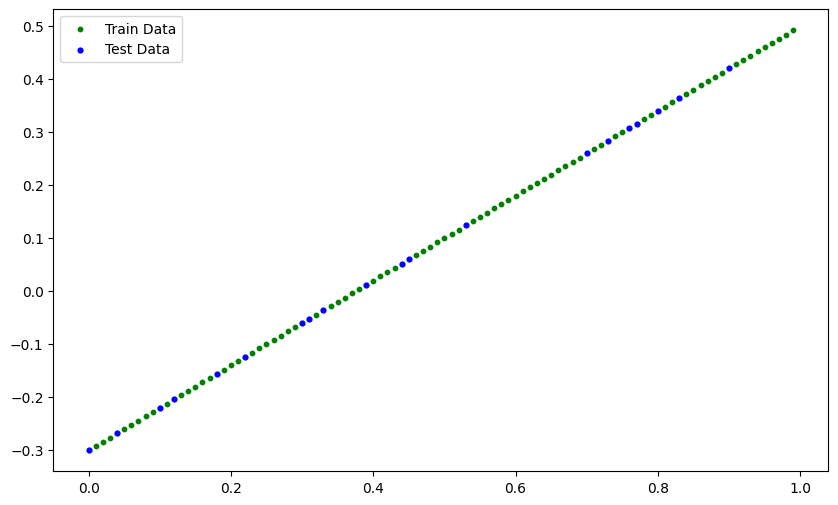

In [ ]:
# Plot predictions
def plot_predictions(train_data = X_train,
                     train_label = y_train,
                     test_data = X_test,
                     test_label = y_test,
                     predictions = None):

    plt.figure(figsize=(10,6))

    # plot train data
    plt.scatter(train_data, train_label, s=10, c='g', label="Train Data")

    # plot test data
    plt.scatter(test_data, test_label, s=12, c='b', label="Test Data")

    # plot predictions
    if predictions is not None:
        plt.scatter(test_data, predictions, s=14, c='r', label="Predicted Data")

    plt.legend()


plot_predictions()

In [ ]:
# Model

class LinearRegressionModel(nn.Module):

    def __init__(self):

        super().__init__()
        self.layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer(x)

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model = LinearRegressionModel().to(device)

# Moving i/p's to device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

next(model.parameters()).device, X_train.device, X_test.device, y_train.device, y_test.device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [ ]:
def Training_loop(lr=0.01, epochs=1000):

    div = 10 if epochs > 100 and epochs < 1000 else 100

    # loss_fn, optimizer
    loss_fn = nn.L1Loss()
    optim = torch.optim.SGD(params=model.parameters(),
                            lr=lr)

    # train loop

    epoch_list = []
    train_loss_list = []
    test_loss_list = []

    for epoch in range(epochs):

        model.train()

        y_pred = model(X_train)
        train_loss = loss_fn(y_pred, y_train)

        optim.zero_grad() # zero the gradients
        train_loss.backward() # back propagation
        optim.step() # gradient descent

        model.eval()

        with torch.inference_mode():
            y_test_pred = model(X_test)
            test_loss = loss_fn(y_test_pred, y_test)



        if epoch % div == 0:
            print(f"Epoch : {epoch} | Train Loss : {train_loss} | Test Loss : {test_loss}")
            epoch_list.append(epoch)
            train_loss_list.append(train_loss.cpu().detach().numpy())
            test_loss_list.append(test_loss.cpu().detach().numpy())

    print(f"Learning Rate : {lr} | Train Loss : {train_loss_list[-1]:.5f} | Test Loss : {test_loss_list[-1]:.5f}")
    return epoch_list, train_loss_list, test_loss_list

In [ ]:
# best case learning rate
# for lr in [0.001, 0.01, 0.05, 0.1, 0.2]:
#    Training_loop(lr, 1000)

In [ ]:
# Best case lr=0.01 for epochs=1000
epoch_list, train_loss_list, test_loss_list = Training_loop(0.01,)

Epoch : 0 | Train Loss : 1.112011194229126 | Test Loss : 1.1019692420959473
Epoch : 100 | Train Loss : 0.11074786633253098 | Test Loss : 0.12295506149530411
Epoch : 200 | Train Loss : 0.06191655620932579 | Test Loss : 0.06734529882669449
Epoch : 300 | Train Loss : 0.0144605478271842 | Test Loss : 0.015329685993492603
Epoch : 400 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Epoch : 500 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Epoch : 600 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Epoch : 700 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Epoch : 800 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Epoch : 900 | Train Loss : 0.008490200154483318 | Test Loss : 0.004383771680295467
Learning Rate : 0.01 | Train Loss : 0.00849 | Test Loss : 0.00438


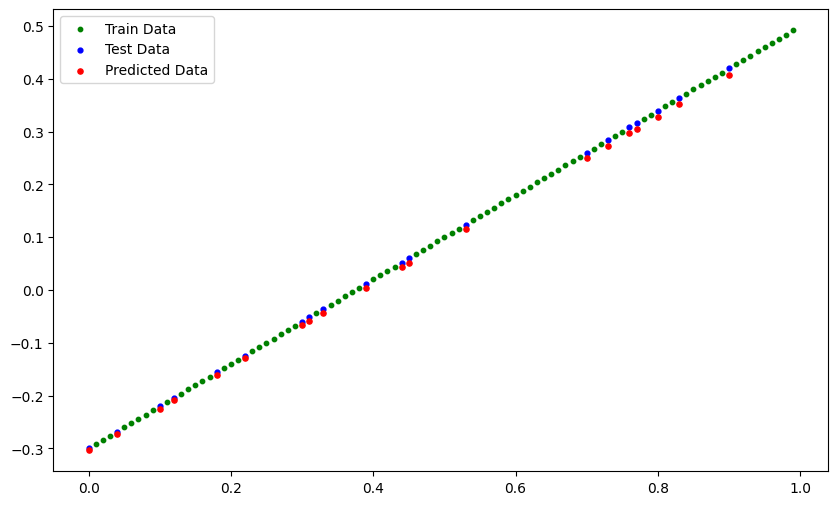

In [ ]:
# Calculate Predictions
with torch.inference_mode():
    y_pred = model(X_test)

# plot predictions
plot_predictions(predictions=y_pred.cpu())

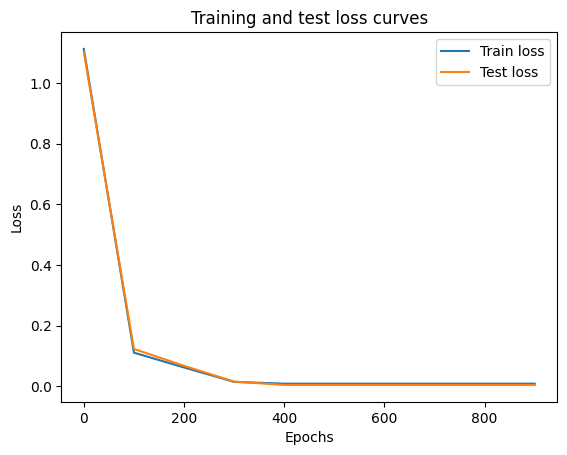

In [ ]:
# Plot the loss curves
plt.plot(epoch_list, train_loss_list, label="Train loss")
plt.plot(epoch_list, test_loss_list, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();